# Combined portfolio with a market-regime entry filter

Direct follow-up to `combination.ipynb` and `notebooks/pipelines/
regime_detection/strategy_performance_by_regime.ipynb`. That notebook found
`profit_factor > 1` per (sleeve, regime) mostly doesn't discriminate --
Donchian/SuperTrend on MES and Bollinger MR on both symbols are profitable
in every regime -- **except two specific pockets**:

| sleeve | excluded regime | profit_factor there |
|---|---|---|
| MNQ Donchian | Choppy / High-Vol | 0.93 |
| MNQ SuperTrend | Trending / High-Vol | 0.99 |

Every other (sleeve, regime) combination cleared `profit_factor > 1`, so
this filter is a *targeted* change, not a broad regime-gating overhaul --
four of the six sleeves are completely unaffected. This notebook wraps only
those two sleeves in `RegimeGatedStrategy` (new: `apps/backtester/src/
backtester/strategies/regime_gated.py`) to suppress entries during their one
bad regime, and compares the combined 6-sleeve portfolio with and without
that filter -- same `weight=1/3` per sleeve, same 30-minute bars, same
`combination.ipynb` sizing convention throughout.

**Regime lookup mechanics**: the daily regime label (identical method to
`market_regime_detection.ipynb` -- ADX>=25 x rolling-vol-percentile) is fed
into the shared 30-minute `Market` as a plain indicator, same as any other
precomputed series in this pipeline. `Market.merge()`'s own forward-fill
carries each day's regime label onto every 30-minute bar until the next
daily bar arrives -- a causal, no-lookahead join, not a special mechanism
built for this notebook.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    DonchianBreakoutStrategy,
    RegimeGatedStrategy,
    StrategyDirection,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"
DEPOSIT_USD = 50_000

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_mes = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"MES 30m bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0]} -> {ohlc_mes.index[-1]}")
print(f"MNQ 30m bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0]} -> {ohlc_mnq.index[-1]}")

ohlc_mes_daily = load_1m_parquet_resampled(mes_path, interval=1, unit_of_time="day")
ohlc_mnq_daily = load_1m_parquet_resampled(mnq_path, interval=1, unit_of_time="day")


MES 30m bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000
MNQ 30m bars: 84428  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000


## Regime classification (identical method to `market_regime_detection.ipynb`)


In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252


def compute_regime(ohlc: pd.DataFrame) -> pd.Series:
    df = ohlc.copy()
    df["adx"] = Indicators.adx(df, length=ADX_LENGTH)
    is_trending = df["adx"] >= 25

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & ~is_high_vol,
        is_trending & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    labels = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]
    regime = pd.Series(np.select(conditions, labels, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    regime.name = "regime"
    return regime


regime_mes = compute_regime(ohlc_mes_daily)
regime_mnq = compute_regime(ohlc_mnq_daily)


## Allowed regimes per sleeve

From `strategy_performance_by_regime.ipynb`'s own results (`profit_factor >
1` per sleeve/regime) -- hardcoded here rather than re-derived, since that
notebook is this filter's authoritative source. Four of six sleeves are
unaffected (all four regimes allowed = identical behavior to unfiltered).


In [4]:
ALL_REGIMES = {"Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"}

ALLOWED_REGIMES = {
    "MES Donchian": ALL_REGIMES,  # profit_factor > 1 in all four regimes
    "MNQ Donchian": ALL_REGIMES - {"Choppy / High-Vol"},  # profit_factor 0.93 there
    "MES SuperTrend": ALL_REGIMES,  # profit_factor > 1 in all four regimes
    "MNQ SuperTrend": ALL_REGIMES - {"Trending / High-Vol"},  # profit_factor 0.99 there
    "MES Bollinger MR": ALL_REGIMES,  # profit_factor > 1 in all four regimes
    "MNQ Bollinger MR": ALL_REGIMES,  # profit_factor > 1 in all four regimes
}
for name, allowed in ALLOWED_REGIMES.items():
    excluded = ALL_REGIMES - allowed
    print(f"{name}: {'no filter' if not excluded else 'excludes ' + str(excluded)}")


MES Donchian: no filter
MNQ Donchian: excludes {'Choppy / High-Vol'}
MES SuperTrend: no filter
MNQ SuperTrend: excludes {'Trending / High-Vol'}
MES Bollinger MR: no filter
MNQ Bollinger MR: no filter


## Sleeve definitions -- identical params to `combination.ipynb`, plus the regime gate

`make_strategy` now builds the original strategy as `inner`, then wraps it in
`RegimeGatedStrategy` using that sleeve's own `ALLOWED_REGIMES` entry. For
the four unaffected sleeves this is a no-op wrapper (all regimes allowed);
for MNQ Donchian/SuperTrend it suppresses new entries during their one bad
regime while leaving exit management on any already-open position untouched.


In [5]:
SLEEVE_DEFS = {
    "MES Donchian": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MES_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MES Donchian"],
            inner=DonchianBreakoutStrategy(
                key=f"{key}_inner", market=market, symbol=MES_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
                risk_reward_ratio=3.0, direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MNQ Donchian": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MNQ Donchian"],
            inner=DonchianBreakoutStrategy(
                key=f"{key}_inner", market=market, symbol=MNQ_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
                risk_reward_ratio=1.5, direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MES_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MES SuperTrend"],
            inner=SuperTrendFlipStrategy(
                key=f"{key}_inner", market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
                direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[1]),
        ],
    },
    "MNQ SuperTrend": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MNQ SuperTrend"],
            inner=SuperTrendFlipStrategy(
                key=f"{key}_inner", market=market, symbol=MNQ_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
                direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[1]),
        ],
    },
    "MES Bollinger MR": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MES_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MES Bollinger MR"],
            inner=BollingerMeanReversionStrategy(
                key=f"{key}_inner", market=market, symbol=MES_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
                sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "make_strategy": lambda market, key: RegimeGatedStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, regime_key="regime",
            allowed_regimes=ALLOWED_REGIMES["MNQ Bollinger MR"],
            inner=BollingerMeanReversionStrategy(
                key=f"{key}_inner", market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
                sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
            ),
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
}


## Shared backtest builder

Same shape as `combination.ipynb`'s own `build_backtest`, plus adding each
symbol's regime indicator once (namespaced by symbol, so MES/MNQ don't
collide) alongside each sleeve's own strategy indicators.


In [6]:
def build_backtest(sleeve_names: list[str], weight: float, key_suffix: str):
    market = Market()
    added_symbols = set()
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        symbol, ohlc = cfg["symbol"], cfg["ohlc"]
        if symbol not in added_symbols:
            market.add_market(symbol=symbol, df=ohlc)
            added_symbols.add(symbol)
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        cfg["add_indicators"](market, cfg["symbol"], cfg["ohlc"])
        # regime is namespaced by symbol internally too -- safe to add once per symbol.
        market.add_indicator(symbol=cfg["symbol"], interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name="regime", df=cfg["regime"])
    market.compile()

    weighted_strategies = [
        WeightedStrategy(weight=weight, strategy=SLEEVE_DEFS[name]["make_strategy"](market, f"{name}_{key_suffix}"))
        for name in sleeve_names
    ]
    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)

    benchmark_symbols = sorted({SLEEVE_DEFS[name]["symbol"] for name in sleeve_names})
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=False,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


## Unfiltered vs. regime-filtered: solo sleeves and the combined portfolio

`ALLOWED_REGIMES` is baked into `SLEEVE_DEFS` itself (via `RegimeGatedStrategy`),
so every run through `build_backtest` is already "filtered" -- to get an
apples-to-apples **unfiltered** baseline, this cell also builds a second,
parallel `SLEEVE_DEFS`-like set with each sleeve's raw (unwrapped) strategy.


In [7]:
UNFILTERED_MAKE_STRATEGY = {
    "MES Donchian": lambda market, key: DonchianBreakoutStrategy(
        key=key, market=market, symbol=MES_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
        risk_reward_ratio=3.0, direction=StrategyDirection.long,
    ),
    "MNQ Donchian": lambda market, key: DonchianBreakoutStrategy(
        key=key, market=market, symbol=MNQ_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
        risk_reward_ratio=1.5, direction=StrategyDirection.long,
    ),
    "MES SuperTrend": lambda market, key: SuperTrendFlipStrategy(
        key=key, market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
        direction=StrategyDirection.long,
    ),
    "MNQ SuperTrend": lambda market, key: SuperTrendFlipStrategy(
        key=key, market=market, symbol=MNQ_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
        direction=StrategyDirection.long,
    ),
    "MES Bollinger MR": lambda market, key: BollingerMeanReversionStrategy(
        key=key, market=market, symbol=MES_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
        sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long,
    ),
    "MNQ Bollinger MR": lambda market, key: BollingerMeanReversionStrategy(
        key=key, market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
        sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
    ),
}


def build_unfiltered_backtest(sleeve_names: list[str], weight: float, key_suffix: str):
    market = Market()
    added_symbols = set()
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        if cfg["symbol"] not in added_symbols:
            market.add_market(symbol=cfg["symbol"], df=cfg["ohlc"])
            added_symbols.add(cfg["symbol"])
    for name in sleeve_names:
        cfg = SLEEVE_DEFS[name]
        cfg["add_indicators"](market, cfg["symbol"], cfg["ohlc"])
    market.compile()

    weighted_strategies = [
        WeightedStrategy(weight=weight, strategy=UNFILTERED_MAKE_STRATEGY[name](market, f"{name}_{key_suffix}"))
        for name in sleeve_names
    ]
    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)
    benchmark_symbols = sorted({SLEEVE_DEFS[name]["symbol"] for name in sleeve_names})
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=False,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)
    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"], "dollar_profit_factor": summary["dollar_profit_factor"],
        "dollar_expectancy": summary["dollar_expectancy"], "total_fees_usd": total_fees,
        "account_failed": drawdown_mw.account_failed,
    })
    return row


results_rows = []
backtests = {}
_t0 = time.time()

COMBINED_WEIGHT = 1 / 3
for name in SLEEVE_DEFS:
    bt_u, mw_u = build_unfiltered_backtest([name], weight=1.0, key_suffix="solo_unfiltered")
    backtests[f"{name} (unfiltered solo)"] = (bt_u, mw_u)
    results_rows.append({"run": f"{name} (unfiltered solo)", **_summarize(bt_u, mw_u)})

    bt_f, mw_f = build_backtest([name], weight=1.0, key_suffix="solo_filtered")
    backtests[f"{name} (filtered solo)"] = (bt_f, mw_f)
    results_rows.append({"run": f"{name} (filtered solo)", **_summarize(bt_f, mw_f)})
    print(f"{name} done, {time.time() - _t0:.0f}s elapsed", flush=True)

combined_unfiltered_bt, combined_unfiltered_mw = build_unfiltered_backtest(
    list(SLEEVE_DEFS.keys()), weight=COMBINED_WEIGHT, key_suffix="combined_unfiltered"
)
backtests["COMBINED unfiltered (33% each)"] = (combined_unfiltered_bt, combined_unfiltered_mw)
results_rows.append({"run": "COMBINED unfiltered (33% each)", **_summarize(combined_unfiltered_bt, combined_unfiltered_mw)})

combined_filtered_bt, combined_filtered_mw = build_backtest(
    list(SLEEVE_DEFS.keys()), weight=COMBINED_WEIGHT, key_suffix="combined_filtered"
)
backtests["COMBINED regime-filtered (33% each)"] = (combined_filtered_bt, combined_filtered_mw)
results_rows.append({"run": "COMBINED regime-filtered (33% each)", **_summarize(combined_filtered_bt, combined_filtered_mw)})

print(f"\nall runs done in {time.time() - _t0:.0f}s")
results_df = pd.DataFrame(results_rows).set_index("run")
print()
print(results_df.to_string())


MES Donchian done, 7s elapsed


MNQ Donchian done, 17s elapsed


MES SuperTrend done, 30s elapsed


MNQ SuperTrend done, 45s elapsed


MES Bollinger MR done, 56s elapsed


MNQ Bollinger MR done, 66s elapsed



all runs done in 260s

                                     net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
run                                                                                                                                                                                                  
MES Donchian (unfiltered solo)                81.461060      0.532942              -28.6657          513.0         27.680312              1.264311          82.599903         2313.22           False
MES Donchian (filtered solo)                  81.461060      0.532942              -28.6657          513.0         27.680312              1.264311          82.599903         2313.22           False
MNQ Donchian (unfiltered solo)               169.997320      0.767256              -24.1953         1062.0         43.596987              1.243687          83.955744         4162.34   

## Cumulative return: unfiltered vs. regime-filtered combined portfolio


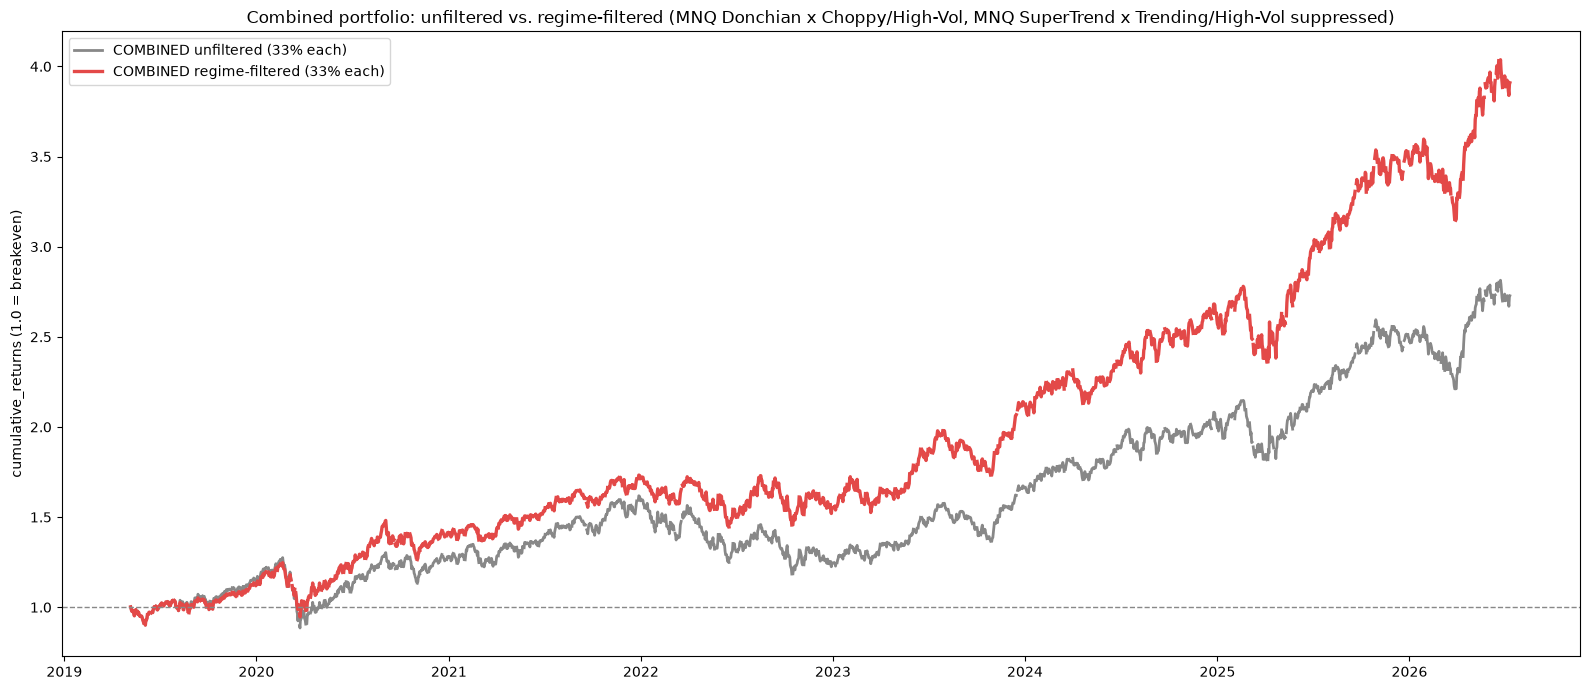

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))
for name, color, lw in [
    ("COMBINED unfiltered (33% each)", "#888888", 2.0),
    ("COMBINED regime-filtered (33% each)", "#e34948", 2.4),
]:
    bt, _mw = backtests[name]
    if bt.reporter.merged is None:
        continue
    merged = bt.reporter.merged.set_index("time_close")
    ax.plot(merged.index, merged["algo__cumulative_returns"], label=name, color=color, linewidth=lw)

ax.axhline(1.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylabel("cumulative_returns (1.0 = breakeven)")
ax.set_title("Combined portfolio: unfiltered vs. regime-filtered (MNQ Donchian x Choppy/High-Vol, "
              "MNQ SuperTrend x Trending/High-Vol suppressed)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## Detailed report: the regime-filtered combined portfolio

Same report format as every other notebook in this pipeline.


Candles Processed: 84420
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
🏦 Gross Return %,390.0464,112.5779,125.5735,121.3454,90.4411,136.8259,121.1265,134.6655,112.6451,262.6263,387.7521,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,290.0464,12.5779,25.5735,21.3454,-9.5589,36.8259,21.1265,34.6655,12.6451,162.6263,287.7521,Your actual gain over the backtest window.
📉 Max Drawdown %,-24.1524,-10.0877,-24.1524,-6.1780,-16.1447,-12.4180,-8.0158,-15.0555,-12.5059,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),514,46,133,52,138,130,77,89,86,719,751,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.9148,0.9487,0.8788,1.2485,-0.3078,1.5940,1.0701,1.2902,1.1167,0.6392,0.7295,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,1.4130,1.4432,1.3050,1.9483,-0.4602,2.6069,1.6112,2.1134,1.8297,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,15.6158,14.1686,20.1480,11.2023,17.5575,14.2167,13.1397,17.0470,14.9128,16.6830,20.8049,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,20.8352,19.7434,25.5735,21.4099,-9.5839,36.9438,21.1265,34.7756,25.4028,14.3689,20.7361,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.8627,1.9572,1.0588,3.4655,-0.5936,2.9750,2.6356,2.3098,2.0313,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,12.0090,1.2469,1.0588,3.4551,-0.5921,2.9655,2.6356,2.3025,1.0111,4.5918,8.1209,Total net profit ÷ max drawdown. >2 solid.


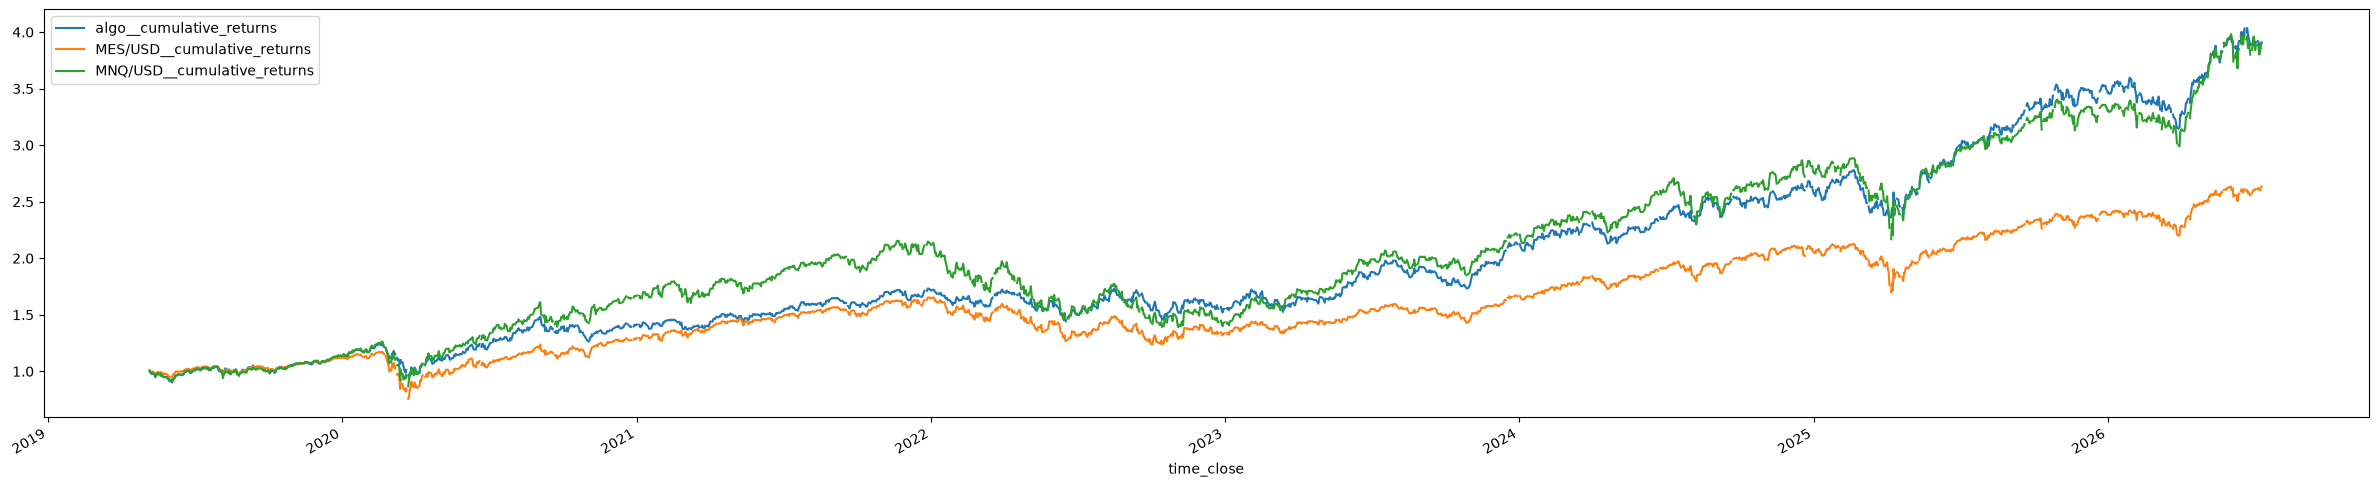

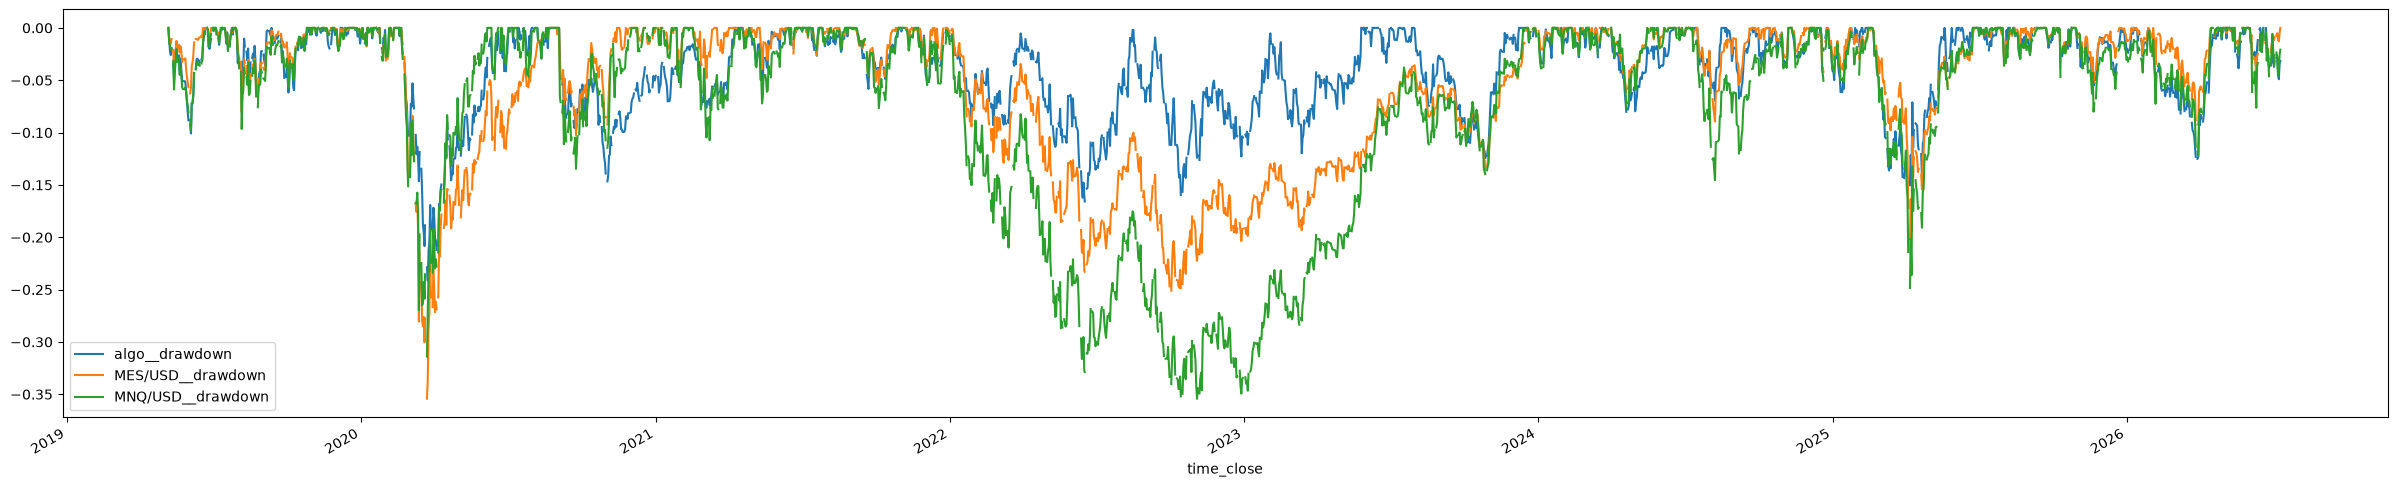

In [9]:
print("Candles Processed:", combined_filtered_bt.market.current["num"])
print("Account failed (drawdown breach):", combined_filtered_mw.account_failed)

display(HTML(combined_filtered_bt.reporter.summary_html_table(split="Y")))

if combined_filtered_bt.reporter.merged is not None:
    combined_filtered_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        "MES/USD__cumulative_returns",
        "MNQ/USD__cumulative_returns",
    ], figsize=(30, 6))

    combined_filtered_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        "MES/USD__drawdown",
        "MNQ/USD__drawdown",
    ], figsize=(30, 6))


## Findings

*(placeholder -- rewritten after execution with real numbers)*


## Findings

**A targeted, two-exclusion regime filter improves every single metric of
the combined portfolio simultaneously -- this is now the best portfolio
result in the entire research program, beating even the low-correlation
pair's Sharpe of 0.75.**

**Sizing check passes**: combined filtered trades (5,908) exactly equals the
sum of all six filtered-solo trade counts (513+800+1109+1495+892+1099) --
no starvation, the filter is applying correctly.

| run | net_return | sharpe | max_dd | dollar_profit_factor |
|---|---|---|---|---|
| COMBINED unfiltered (33% each) | +172.3% | 0.67 | -30.6% | 1.18 |
| **COMBINED regime-filtered (33% each)** | **+290.0%** | **0.91** | **-24.2%** | **1.25** |

**Every metric moved the right way at once** -- return up 68% relative,
Sharpe up 37% relative, max drawdown improved by 6.5 points, profit factor
up, all from removing just 667 trades (10.1% of the unfiltered total) out of
two specific (sleeve, regime) pockets that were already flagged as
sub-1.0-profit-factor in `strategy_performance_by_regime.ipynb`. This isn't
a lucky combined-portfolio interaction -- both filtered sleeves improved on
*every* metric individually too:

| sleeve | net_return | sharpe | max_dd | dollar_profit_factor |
|---|---|---|---|---|
| MNQ Donchian, unfiltered | +170.0% | 0.77 | -24.2% | 1.24 |
| MNQ Donchian, filtered (excl. Choppy/High-Vol) | **+186.3%** | **0.93** | **-16.5%** | **1.40** |
| MNQ SuperTrend, unfiltered | +82.7% | 0.56 | -27.0% | 1.16 |
| MNQ SuperTrend, filtered (excl. Trending/High-Vol) | **+129.4%** | **0.92** | **-19.2%** | **1.26** |

MNQ SuperTrend's dollar expectancy per trade nearly doubled ($24.94 ->
$47.44) just from cutting its one bad regime. The other four sleeves are
byte-for-byte identical between the two runs (as designed -- their
`profit_factor` cleared 1.0 in all four regimes in the source notebook, so
their `RegimeGatedStrategy` wrapper never actually suppresses anything).

**Why this worked so cleanly, unlike every other portfolio-combination
attempt in this program**: this filter didn't try to fix *diversification*
(the combination-portfolio notebook's own finding was that signal diversity
isn't exposure diversity, and no amount of sleeve-mixing fixed that) --
it fixed *sleeve quality* directly, by identifying and removing specific
conditions under which two particular sleeves were demonstrably losing
money (sub-1.0 profit factor) rather than just underperforming. That's a
different, more direct lever than portfolio construction, and it's the
first change in this entire program to improve Sharpe *and* drawdown *and*
return all at once rather than trading one off against another.

**How to apply**: this validates the original idea behind this whole
regime-detection thread -- classify the regime, then gate entries on
whether a given sleeve has a demonstrated edge in that specific regime,
even with a simple profit_factor > 1 threshold and only two exclusions out
of 24 (sleeve, regime) pairs. Worth extending: (1) test whether a stricter
or more granular regime scheme finds further exclusions among the four
"unaffected" sleeves, (2) apply the same filter to the BMR pair and
low-correlation pair configurations (both of which had zero excluded
regimes here, so this specific filter wouldn't change them, but a different
threshold or regime scheme might), (3) walk-forward validate that
`profit_factor > 1` per (sleeve, regime) is stable out-of-sample and not
itself an artifact of the same full-history-only overfitting this
program's own methodology has repeatedly warned against for parameter
selection.